✅ Dataset Loaded Successfully!

--- Basic Statistics ---
Total Number of Materials: 4804
Number of Initial Features: 18
Total Missing Values (NaN): 0


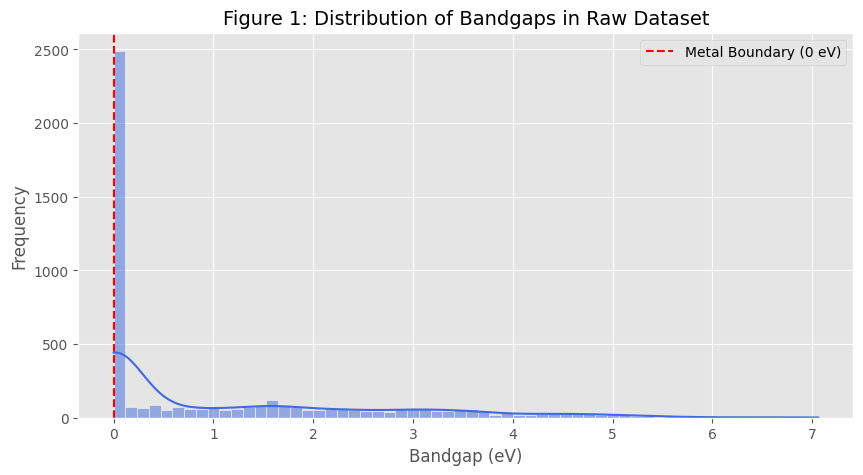


--- Phase Analysis Result ---
Metals found: 2385 (49.65%)
Semiconductors found: 2419 (50.35%)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Settings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')
%matplotlib inline

# Load the brand new, unedited data
try:
    df = pd.read_csv('ML_Final_Sheet.csv')
    print("Dataset Loaded Successfully!")
except FileNotFoundError:
    print("Error: ML_Final_Sheet.csv not found in this folder.")

# 1. Dataset Overview
print("\n  Basic Statistics  ")
print(f"Total Number of Materials: {df.shape[0]}")
print(f"Number of Initial Features: {df.shape[1]}")

# 2. Check for Missing Values (Technical Quality Check)
null_values = df.isnull().sum().sum()
print(f"Total Missing Values (NaN): {null_values}")

# 3. Analyze Target Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['band_gap'], bins=60, kde=True, color='royalblue')
plt.axvline(x=0, color='red', linestyle='--', label='Metal Boundary (0 eV)')
plt.title('Figure 1: Distribution of Bandgaps in Raw Dataset', fontsize=14)
plt.xlabel('Bandgap (eV)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.show()

# 4. Phase Partitioning Logic
metals = df[df['band_gap'] == 0]
semiconductors = df[df['band_gap'] > 0]

metal_perc = (len(metals) / len(df)) * 100
semi_perc = (len(semiconductors) / len(df)) * 100

print(f"\n  Phase Analysis Result  ")
print(f"Metals found: {len(metals)} ({metal_perc:.2f}%)")
print(f"Semiconductors found: {len(semiconductors)} ({semi_perc:.2f}%)")

--- Structural Integrity Audit ---
Materials with multiple phases (Polymorphs): 568
Example of polymorphic formulas:
formula
MAPbI     81
LiMnF3    45
LiFeF3    41
MgSiO3    37
CaSnS3    30
Name: band_gap, dtype: int64


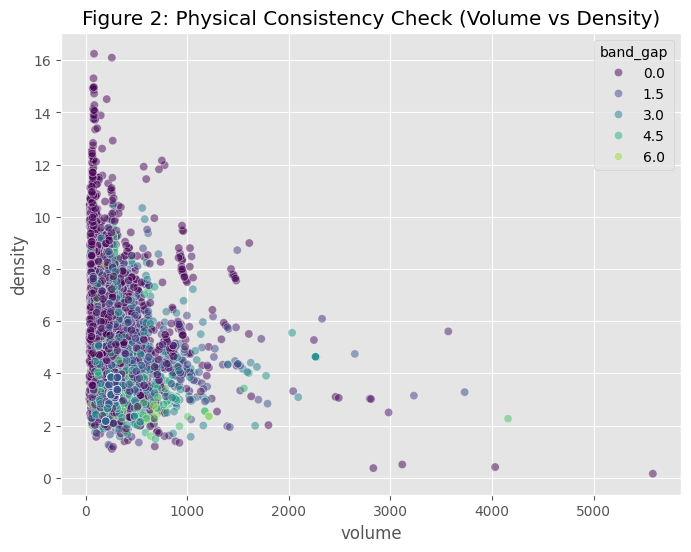


--- Feature Statistics for Dissertation Table 1 ---
                         mean         std        min          max
band_gap             1.104623    1.523450   0.000000     7.061300
rA                   1.208573    0.346424   0.410000     2.530000
rB                   0.799190    0.223961   0.300000     1.660000
rX                   1.127855    0.320859   0.300000     2.200000
chi_A                1.423437    0.608784   0.790000     3.980000
chi_B                1.921655    0.481709   0.820000     3.980000
chi_X                3.039469    0.728974   0.790000     3.980000
EA_A                 0.455799    0.567048  -0.720000     3.612725
EA_B                 0.631280    0.701283  -0.720000     3.612725
EA_X                 1.738794    0.976960  -0.720000     3.612725
tolerance_factor     0.865594    0.120106   0.707214     1.406217
octahedral_factor    0.762335    0.315155   0.197368     3.466667
a                    5.689363    1.896862   2.716358    19.957515
b                    6.

In [2]:
# 1. Structural Duplicate Analysis
# Check if same formula has different bandgaps (Polymorphism)
poly_check = df.groupby('formula')['band_gap'].nunique().sort_values(ascending=False)
multi_phase = poly_check[poly_check > 1]

print("--- Structural Integrity Audit ---")
print(f"Materials with multiple phases (Polymorphs): {len(multi_phase)}")
print(f"Example of polymorphic formulas:\n{multi_phase.head(5)}")

# 2. Physical Law Check (Density vs Volume)
# In physics, these should be inversely related.
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='volume', y='density', hue='band_gap', palette='viridis', alpha=0.5)
plt.title('Figure 2: Physical Consistency Check (Volume vs Density)')
plt.show()

# 3. Statistical Summary for the Thesis Table
stats_table = df.describe().T
print("\n--- Feature Statistics for Dissertation Table 1 ---")
print(stats_table[['mean', 'std', 'min', 'max']])

--- Structural Integrity Audit ---
Total Unique Formulas: 2722
Formulas with multiple phases (Polymorphs): 568

Example of polymorphic formulas (Formula : Count of phases):
formula
MAPbI     81
LiMnF3    45
LiFeF3    41
MgSiO3    37
CaSnS3    30
FAPbI     27
VOF3      23
NaNbO3    20
CsPbI     19
MAPbBr    18
Name: band_gap, dtype: int64


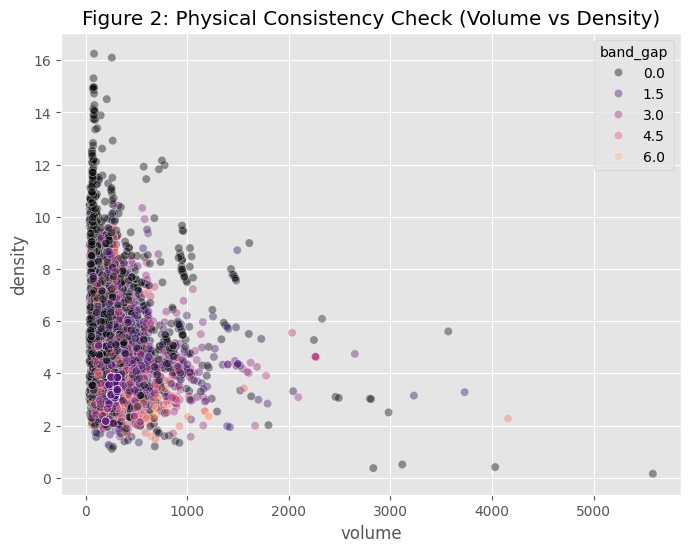


--- Summary Statistics for Chapter 3 ---
                   count        mean         std        min        25%  \
band_gap          4804.0    1.104623    1.523450   0.000000   0.000000   
volume            4804.0  273.873137  310.791554  34.799143  90.151846   
density           4804.0    5.650142    2.261557   0.151653   3.853029   
tolerance_factor  4804.0    0.865594    0.120106   0.707214   0.772758   

                         50%         75%          max  
band_gap            0.007050    1.962450     7.061300  
volume            199.623919  311.943598  5583.926636  
density             5.286081    7.176132    16.250754  
tolerance_factor    0.838309    0.930577     1.406217  


In [3]:
# 1. Structural Duplicate Analysis (Polymorphism)
# Checking how many formulas appear more than once with different bandgaps
poly_check = df.groupby('formula')['band_gap'].nunique().sort_values(ascending=False)
multi_phase = poly_check[poly_check > 1]

print("--- Structural Integrity Audit ---")
print(f"Total Unique Formulas: {df['formula'].nunique()}")
print(f"Formulas with multiple phases (Polymorphs): {len(multi_phase)}")
print(f"\nExample of polymorphic formulas (Formula : Count of phases):")
print(multi_phase.head(10))

# 2. Physical Consistency: Volume vs Density
# Basic Physics: As density increases, volume should decrease (Inverse relationship)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='volume', y='density', hue='band_gap', palette='magma', alpha=0.4)
plt.title('Figure 2: Physical Consistency Check (Volume vs Density)')
plt.show()

# 3. Target Statistics for your Dissertation Table 1
print("\n--- Summary Statistics for Chapter 3 ---")
print(df[['band_gap', 'volume', 'density', 'tolerance_factor']].describe().T)

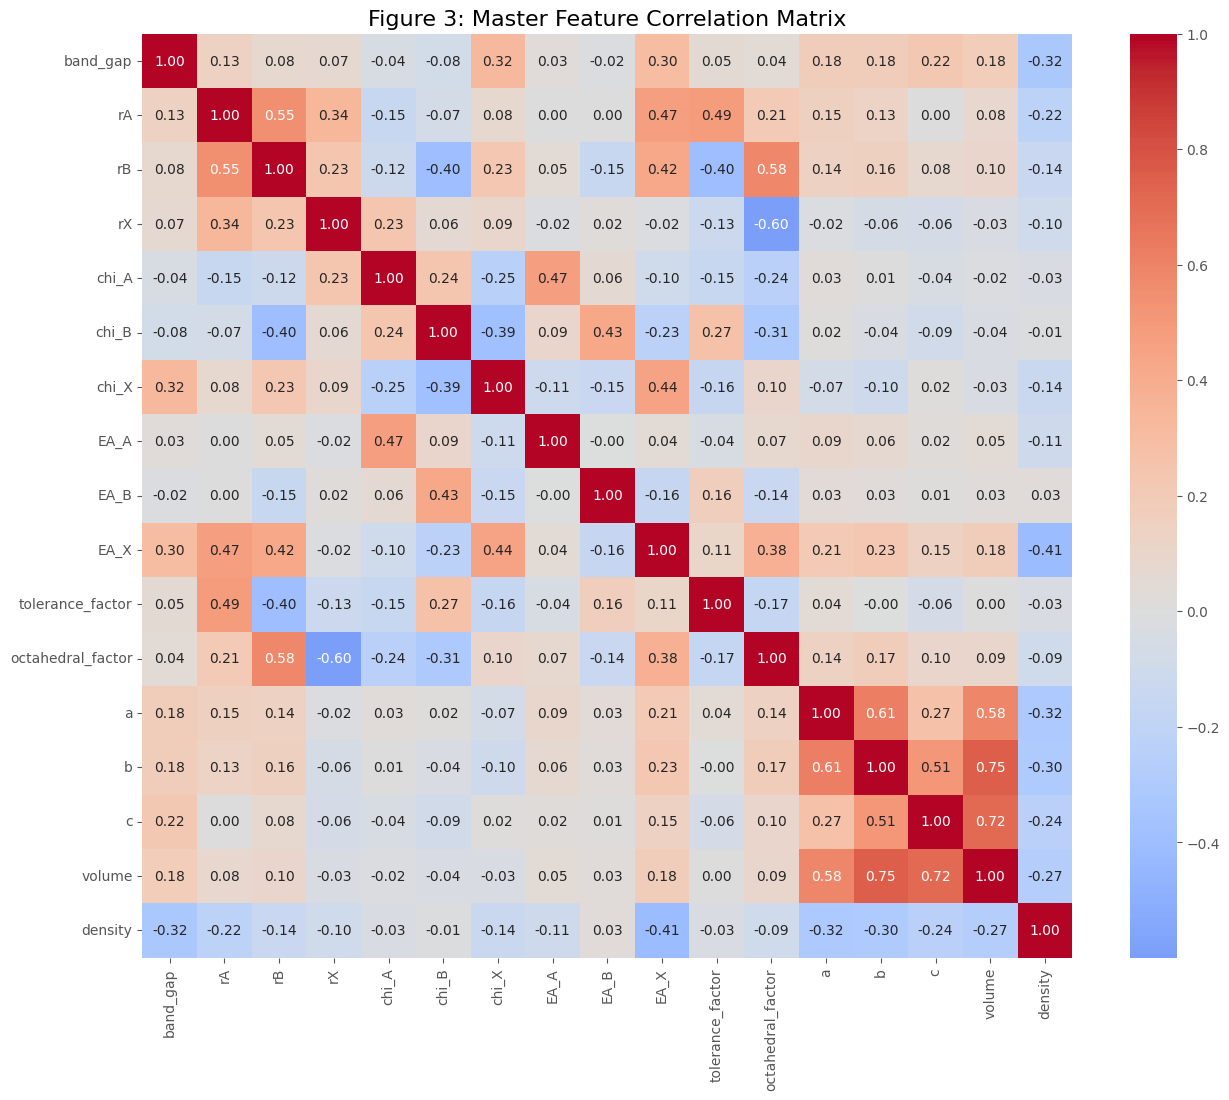

--- Global Redundancy Audit ---
✅ No extreme redundancy found across the full feature set.

--- Physical Drivers of Bandgap (Ranked by Influence) ---
band_gap             1.000000
density              0.320744
chi_X                0.320517
EA_X                 0.300203
c                    0.222849
volume               0.182594
b                    0.180908
a                    0.176296
rA                   0.134862
chi_B                0.081539
rB                   0.080232
rX                   0.068680
tolerance_factor     0.051257
octahedral_factor    0.043777
chi_A                0.040031
EA_A                 0.029244
EA_B                 0.023408
Name: band_gap, dtype: float64


In [6]:
# 1. Select ALL numerical columns mentioned in your list
all_features = [
    'band_gap', 'rA', 'rB', 'rX', 'chi_A', 'chi_B', 'chi_X', 
    'EA_A', 'EA_B', 'EA_X', 'tolerance_factor', 'octahedral_factor', 
    'a', 'b', 'c', 'volume', 'density'
]

# 2. Filter the dataframe to only include these (ensuring no strings cause errors)
numeric_df = df[all_features]

# 3. Calculate Global Correlation
full_corr = numeric_df.corr()

# 4. Plotting the 'Master Heatmap'
plt.figure(figsize=(15, 12))
sns.heatmap(full_corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Figure 3: Master Feature Correlation Matrix', fontsize=16)
plt.show()

# 5. Identifying Multicollinearity across the WHOLE set
# We look for ANY two features that are > 0.95 correlated
upper_full = full_corr.where(np.triu(np.ones(full_corr.shape), k=1).astype(bool))
redundant_all = [column for column in upper_full.columns if any(upper_full[column] > 0.95)]

print("--- Global Redundancy Audit ---")
if len(redundant_all) > 0:
    print(f"⚠️ Highly Redundant Features Found: {redundant_all}")
else:
    print("✅ No extreme redundancy found across the full feature set.")

# 6. Top Physics Drivers (Sorted by absolute correlation with band_gap)
top_drivers = full_corr['band_gap'].abs().sort_values(ascending=False)
print("\n--- Physical Drivers of Bandgap (Ranked by Influence) ---")
print(top_drivers)

In [7]:
from scipy import stats

# 1. Identify Outliers
z_scores = np.abs(stats.zscore(numeric_df))
outliers = (z_scores > 3).any(axis=1)

print(f"--- Outlier Detection ---")
print(f"Number of rows identified as outliers: {outliers.sum()}")
print(f"Percentage of data affected: {(outliers.sum()/len(df))*100:.2f}%")

# 2. Filter the Data
df_step1_final = df[~outliers]
print(f"Final Step 1 Dataset Size: {df_step1_final.shape}")

--- Outlier Detection ---
Number of rows identified as outliers: 748
Percentage of data affected: 15.57%
Final Step 1 Dataset Size: (4056, 18)
